Load the Data

In [152]:
import numpy as np
import pandas as pd

df = pd.read_csv("logistics_shipments.csv")
df.head()

,Shipment_ID,Order_Date,Dispatch_Date,Delivery_Date,Expected_Delivery_Date,Customer_ID,Region,City,Carrier,Product_Category,...,Delay_in_Days,Delayed,Delay_Reason,SLA_Breached,Customer_Rating,Return_Requested,Return_Reason,Revenue_USD,Warehouse_ID,Weekday
0,SHP000000,2025-03-26,2025-03-29,2025-04-02,2025-04-02,CUST2424,North,East Nancyberg,UPS,Electronics,...,0,False,Not Applicable,False,5.0,False,Not Requested,282.10,WH_009,Wednesday
1,SHP000001,2025-04-19,2025-04-21,2025-04-26,2025-04-25,CUST7873,North,West Scott,DHL,Electronics,...,1,True,Weather,True,4.5,False,Not Requested,168.48,WH_009,Saturday
2,SHP000002,2024-12-04,2024-12-05,2024-12-12,2024-12-12,CUST3547,Central,North Kristin,LocalCarrier2,Automotive,...,0,False,Not Applicable,False,4.4,False,Not Requested,118.10,WH_005,Thursday
3,SHP000003,2024-12-12,2024-12-15,2024-12-25,2024-12-22,CUST7201,East,Snyderborough,UPS,Furniture,...,3,True,Weather,False,3.3,True,Wrong Product,111.27,WH_002,Wednesday
4,SHP000004,2024-12-25,2024-12-28,2025-01-04,2025-01-04,CUST4733,East,East Alexandermouth,LocalCarrier1,Automotive,...,0,False,Not Applicable,False,4.1,False,Not Requested,66.97,WH_001,Saturday


Understand the shape and structure of the dataset.

In [153]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Shipment_ID             15000 non-null  object 
 1   Order_Date              15000 non-null  object 
 2   Dispatch_Date           15000 non-null  object 
 3   Delivery_Date           15000 non-null  object 
 4   Expected_Delivery_Date  15000 non-null  object 
 5   Customer_ID             15000 non-null  object 
 6   Region                  15000 non-null  object 
 7   City                    15000 non-null  object 
 8   Carrier                 15000 non-null  object 
 9   Product_Category        15000 non-null  object 
 10  Shipment_Mode           15000 non-null  object 
 11  Distance_km             15000 non-null  int64  
 12  Weight_kg               15000 non-null  float64
 13  Shipping_Cost_USD       15000 non-null  float64
 14  Delay_in_Days           15000 non-null

In [154]:
#Convert date columns to datetime format for time-based analysis
date_cols = ['Order_Date', 'Dispatch_Date', 'Delivery_Date', 'Expected_Delivery_Date']
df[date_cols] = df[date_cols].apply(pd.to_datetime)

df[date_cols].dtypes

Order_Date                datetime64[ns]
Dispatch_Date             datetime64[ns]
Delivery_Date             datetime64[ns]
Expected_Delivery_Date    datetime64[ns]
dtype: object

In [155]:
df.isnull().sum()

Shipment_ID               0
Order_Date                0
Dispatch_Date             0
Delivery_Date             0
Expected_Delivery_Date    0
Customer_ID               0
Region                    0
City                      0
Carrier                   0
Product_Category          0
Shipment_Mode             0
Distance_km               0
Weight_kg                 0
Shipping_Cost_USD         0
Delay_in_Days             0
Delayed                   0
Delay_Reason              0
SLA_Breached              0
Customer_Rating           0
Return_Requested          0
Return_Reason             0
Revenue_USD               0
Warehouse_ID              0
Weekday                   0
dtype: int64

Exploratory Data Analysis (EDA)

In [156]:
#Value counts for categorical columns
cat_cols = ['Region', 'Carrier', 'Shipment_Mode', 'Product_Category', 'Delay_Reason', 'Return_Reason']
for col in cat_cols:
    print(df[col].value_counts())

Region
South      3051
West       3051
East       2972
North      2970
Central    2956
Name: count, dtype: int64
Carrier
LocalCarrier1    3091
FedEx            3010
LocalCarrier2    2990
DHL              2955
UPS              2954
Name: count, dtype: int64
Shipment_Mode
Standard     7505
Express      3654
Same-Day     2373
Overnight    1468
Name: count, dtype: int64
Product_Category
Electronics          3796
Apparel              3001
Furniture            2261
Food                 2248
Automotive           2184
Medical Equipment    1510
Name: count, dtype: int64
Delay_Reason
Not Applicable    11674
Weather            1333
Traffic            1150
Hub Delay           513
Custom Hold         330
Name: count, dtype: int64
Return_Reason
Not Requested    13889
Damaged            477
Wrong Product      387
Late               247
Name: count, dtype: int64


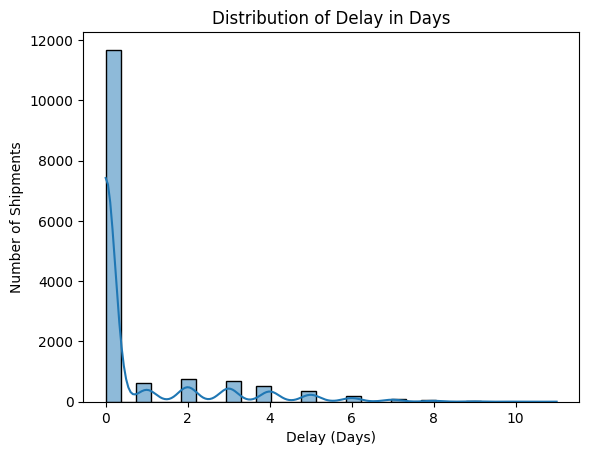

In [157]:
#Distribution of shipment delays
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Delay_in_Days'], bins=30, kde=True)
plt.title("Distribution of Delay in Days")
plt.xlabel("Delay (Days)")
plt.ylabel("Number of Shipments")
plt.show()

Conclusion:
Majority of shipments have 0–2 days delay.
Long tail: some shipments have delays >10 days.

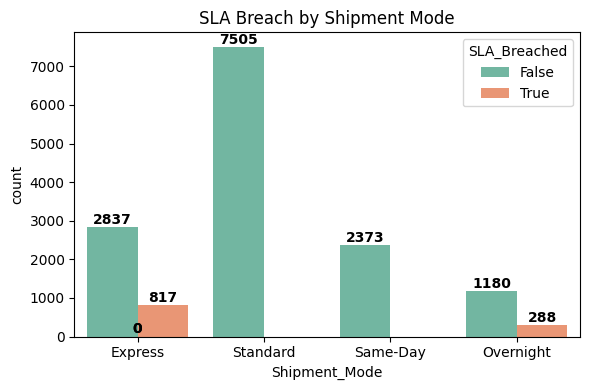

In [210]:
#Shipment Mode vs SLA Breach
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Shipment_Mode', hue='SLA_Breached', data=df, palette='Set2')
plt.title("SLA Breach by Shipment Mode")
plt.tight_layout()


for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  
        height + 5,                     
        f'{int(height)}',             
        ha='center', va='bottom',
        color='black', fontsize=10, fontweight='bold'
    )

plt.show()


Conclusion:
Standard and Express modes have higher SLA breach sensitivity.
Standard mode rarely breaches SLA (more leeway).

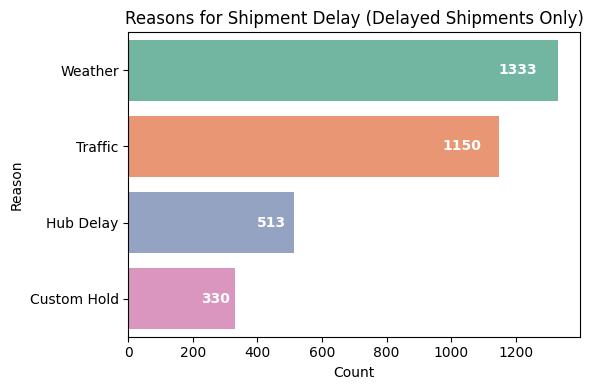

In [213]:
#Shipment Delay vs Reason
df_delayed = df[(df['Delayed'] == True) & (df['Delay_Reason'] != 'Not Applicable')]

plt.figure(figsize=(6,4))
ax = sns.countplot(
    y='Delay_Reason',
    data=df_delayed,
    order=df_delayed['Delay_Reason'].value_counts().index,
    palette='Set2'
)

plt.title("Reasons for Shipment Delay (Delayed Shipments Only)")
plt.xlabel("Count")
plt.ylabel("Reason")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width - (width * 0.05),  # Slightly left inside bar
        p.get_y() + p.get_height() / 2,
        int(width),
        ha='right',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Conclusion:
Top reasons include Weather and Traffic.
Useful for operational improvement.

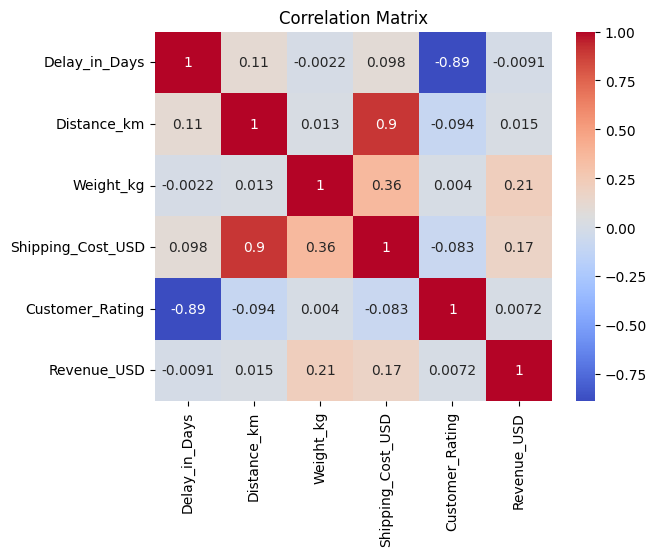

In [160]:
#Correlation matrix (numerical fields)
corr = df[['Delay_in_Days', 'Distance_km', 'Weight_kg', 'Shipping_Cost_USD', 'Customer_Rating', 'Revenue_USD']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Conclusion:
Delay_in_Days has negative correlation with Customer_Rating.
Shipping cost is more correlated with weight and distance (as expected).


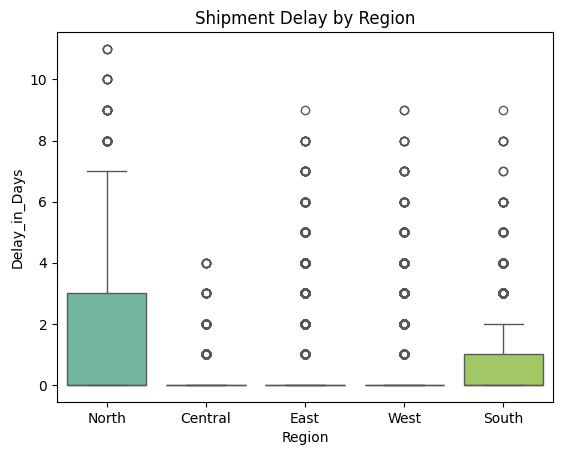

In [161]:
#Regional delays comparison
sns.boxplot(x='Region', y='Delay_in_Days', data=df, palette='Set2')
plt.title("Shipment Delay by Region")
plt.show()


Conclusion:
North and South regions show more delay variance.
Could indicate logistics issues in those areas.

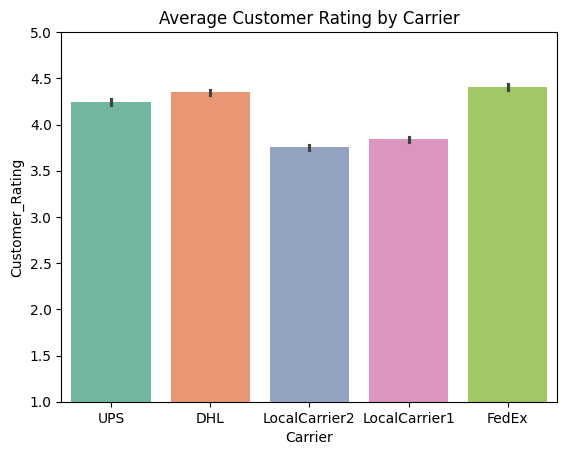

In [162]:
#Average customer rating by carrier
sns.barplot(x='Carrier', y='Customer_Rating', data=df, palette='Set2')
plt.title("Average Customer Rating by Carrier")
plt.ylim(1, 5)
plt.show()


Conclusion:
Some carriers consistently perform better -FedEx, UPS, DHL.
Others (LocalCarrier1/2) show lower satisfaction — investigate further.

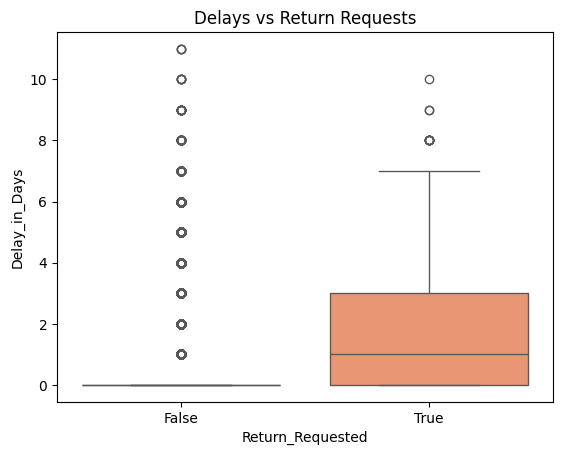

In [163]:
#Return requests vs Delays
sns.boxplot(x='Return_Requested', y='Delay_in_Days', data=df, palette='Set2')
plt.title("Delays vs Return Requests")
plt.show()


Conclusion:
Returned orders have higher average delay.
Late delivery is a strong indicator of potential return.

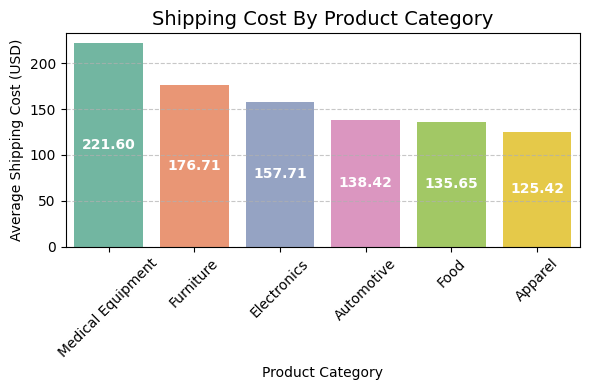

In [218]:
#Group by Shipping Cost by Product Category
gb1 = df.groupby('Product_Category')['Shipping_Cost_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=gb1.index, y=gb1.values, palette='Set2')

plt.title('Shipping Cost By Product Category', fontsize=14)
plt.ylabel('Average Shipping Cost (USD)')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels inside bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2, height / 2, f'{height:.2f}', ha='center', va='center', color='white', fontsize=10, fontweight='bold'
    )

plt.show()


Conclusion:
Medical Equipment incurs the highest average shipping cost among all product categories, followed by Furniture and Electronics.

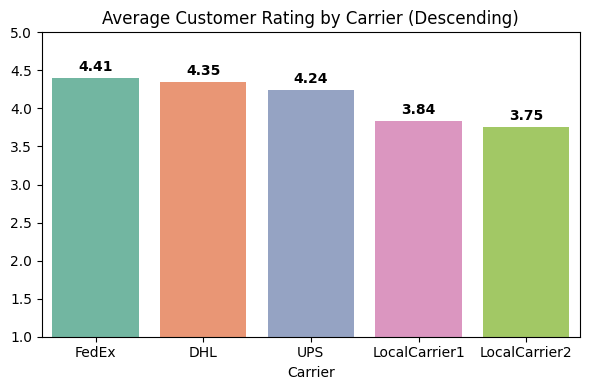

In [217]:
#Group by Customer Rating by Product Category
avg_rating = df.groupby('Carrier')['Customer_Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='Set2')
plt.title("Average Customer Rating by Carrier (Descending)")
plt.ylim(1, 5)

# Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.05,  # just above the bar
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

Conclusion:
FedEx receives the highest average customer rating, followed by DHL and UPS.

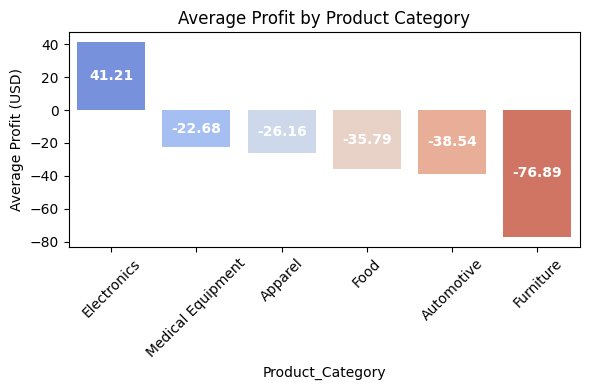

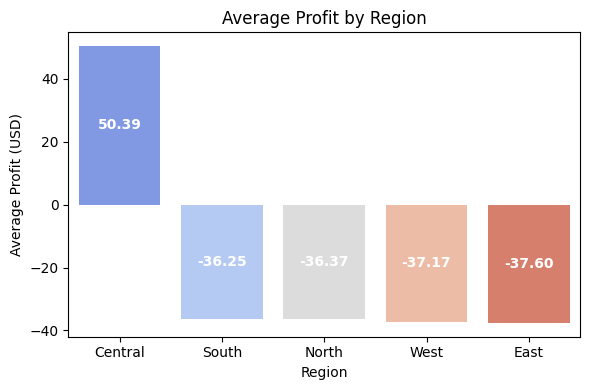

In [220]:
df['Profit'] = df['Revenue_USD'] - df['Shipping_Cost_USD']

# Profit by Product Category
profit_by_category = df.groupby('Product_Category')['Profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = sns.barplot(x=profit_by_category.index, y=profit_by_category.values, palette='coolwarm')
plt.title('Average Profit by Product Category')
plt.ylabel('Average Profit (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2, 
        height/2, 
        f'{height:.2f}', 
        ha='center', va='center', 
        color='white', fontweight='bold'
    )

plt.show()

# Profit by Region
profit_by_region = df.groupby('Region')['Profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')
plt.title('Average Profit by Region')
plt.ylabel('Average Profit (USD)')
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2, 
        height/2, 
        f'{height:.2f}', 
        ha='center', va='center', 
        color='white', fontweight='bold'
    )

plt.show()


Conclusion:
Central Region has achieved maximum prfit while East has least.
Electronics shows maximum profit and furniture has least.

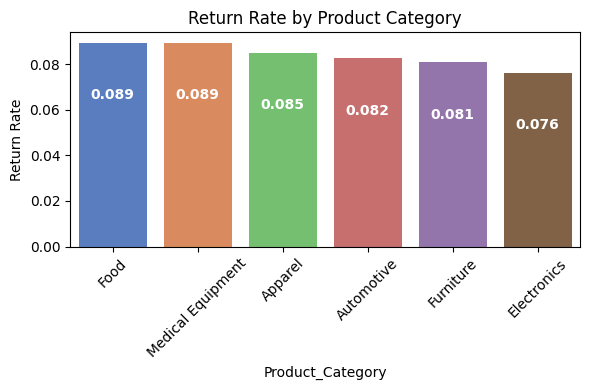

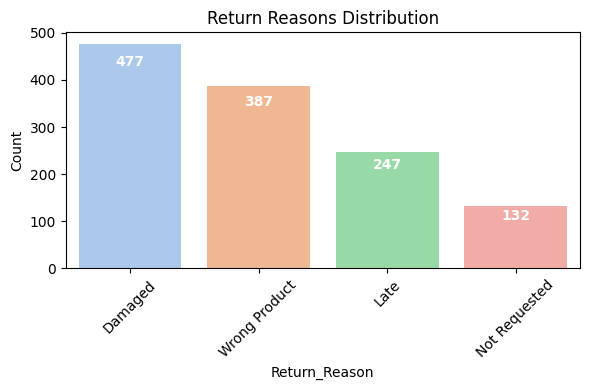

In [222]:
# Return rate by product category with labels inside bars
plt.figure(figsize=(6,4))
ax = sns.barplot(x=return_rate.index, y=return_rate.values, palette='muted')
plt.title('Return Rate by Product Category')
plt.ylabel('Return Rate')
plt.xticks(rotation=45)
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height - 0.02,
        f'{height:.3f}',
        ha='center',
        va='top',
        color='white',
        fontweight='bold'
    )

plt.show()

# Return reason distribution with labels inside bars
plt.figure(figsize=(6,4))
ax = sns.countplot(data=returned_df, x='Return_Reason', order=return_reason_order, palette='pastel')
plt.title('Return Reasons Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height - (0.05*height), 
        f'{int(height)}',
        ha='center',
        va='top',
        color='white',
        fontweight='bold'
    )

plt.show()


Conclusion:
Food and Medical equipments has highest returns.
Maximum return reason is damaged.

Customer Segmentation

In [225]:

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics per customer

# Recency
recency = df.groupby('Customer_ID')['Order_Date'].apply(lambda x: (snapshot_date - x.max()).days)

# Frequency
frequency = df.groupby('Customer_ID')['Order_Date'].count()

# Monetary
monetary = df.groupby('Customer_ID')['Revenue_USD'].sum()


rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})
rfm

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1000,17,3,335.49
CUST1001,35,3,414.11
CUST1004,4,1,113.35
CUST1007,19,2,209.46
CUST1008,160,2,211.51
...,...,...,...
CUST9992,76,1,239.68
CUST9993,143,2,191.80
CUST9994,187,1,152.24


In [226]:
rfm = rfm[rfm['Monetary'] > 0]

#Scale RFM values for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

#Apply KMeans clustering into 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_
rfm['Cluster']

Customer_ID
CUST1000    0
CUST1001    0
CUST1004    1
CUST1007    1
CUST1008    3
           ..
CUST9992    1
CUST9993    3
CUST9994    3
CUST9996    3
CUST9997    0
Name: Cluster, Length: 7302, dtype: int32

In [193]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Recency')
cluster_summary 

,Recency,Frequency,Monetary
Cluster,,,
2,41.581633,4.309949,627.338253
1,52.573139,1.481608,173.347233
0,65.904928,2.698357,384.875027
3,173.153846,1.259788,161.824136


In [227]:
category_map = {}
for i, cluster in enumerate(cluster_summary.index):
    if i == 0:
        category_map[cluster] = 'Best Customers'
    elif i == 1:
        category_map[cluster] = 'Loyal Customers'
    elif i == 2:
        category_map[cluster] = 'At Risk Customers'
    else:
        category_map[cluster] = 'Lost Customers'
        
# Map clusters to categories
rfm['Category'] = rfm['Cluster'].map(category_map)

# Get counts per category
category_counts = rfm['Category'].value_counts().sort_values(ascending=False)
category_counts

Category
Loyal Customers      2338
Lost Customers       2171
At Risk Customers    2009
Best Customers        784
Name: count, dtype: int64

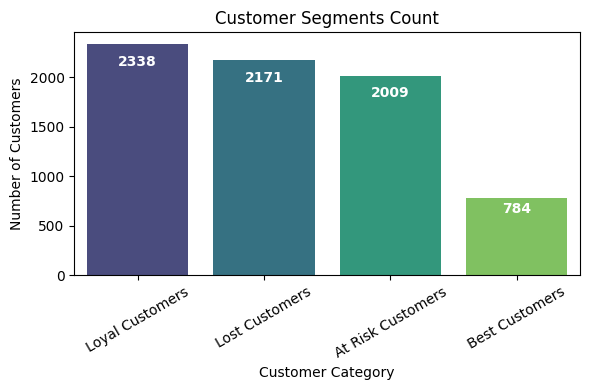

In [228]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Customer Segments Count')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)

# Add data labels inside bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,  # x position: center of the bar
        height - (0.05 * height),        # y position: slightly below the top of bar
        f'{int(height)}',
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

plt.tight_layout()
plt.show()


In [229]:
rfm_reset = rfm.reset_index()
customer_segments = rfm_reset[['Customer_ID', 'Category']]

# Save to CSV
customer_segments.to_csv('customer_segments.csv', index=False)
print("Customer segmentation saved to 'customer_segments.csv'")


Customer segmentation saved to 'customer_segments.csv'


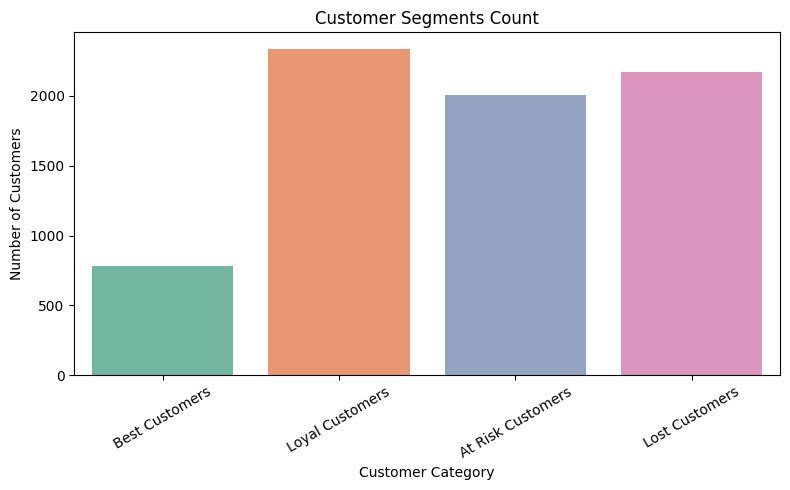

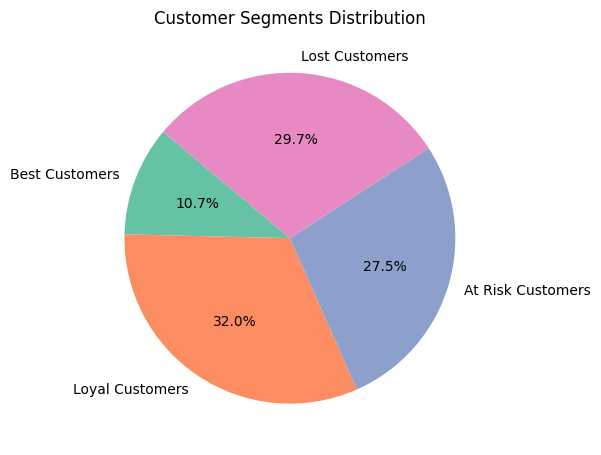

In [ ]:

# Convert 'Order_Date' to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Step 1: Define snapshot date (day after last order)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Step 2: Calculate RFM metrics per customer

# Recency: days since last order
recency = df.groupby('Customer_ID')['Order_Date'].apply(lambda x: (snapshot_date - x.max()).days)

# Frequency: count of orders
frequency = df.groupby('Customer_ID')['Order_Date'].count()

# Monetary: total revenue
monetary = df.groupby('Customer_ID')['Revenue_USD'].sum()

# Combine into one RFM dataframe
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# Filter out customers with zero or negative revenue if any
rfm = rfm[rfm['Monetary'] > 0]

# Step 3: Scale RFM values for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Step 4: Apply KMeans clustering into 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

# Step 5: Assign descriptive category names based on cluster Recency mean
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Recency')

category_map = {}
for i, cluster in enumerate(cluster_summary.index):
    if i == 0:
        category_map[cluster] = 'Best Customers'
    elif i == 1:
        category_map[cluster] = 'Loyal Customers'
    elif i == 2:
        category_map[cluster] = 'At Risk Customers'
    else:
        category_map[cluster] = 'Lost Customers'

rfm['Category'] = rfm['Cluster'].map(category_map)

# Step 6: Plot counts of each category (bar plot)
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Category', order=['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers'], palette='Set2')
plt.title('Customer Segments Count')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Step 7: Plot pie chart for category distribution
plt.figure(figsize=(6,6))
rfm['Category'].value_counts().loc[['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers']].plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=140)
plt.ylabel('')
plt.title('Customer Segments Distribution')
plt.tight_layout()
plt.show()


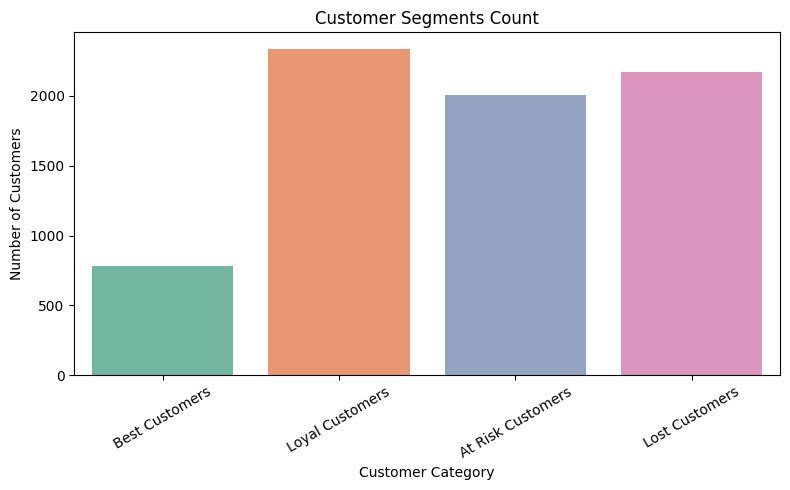

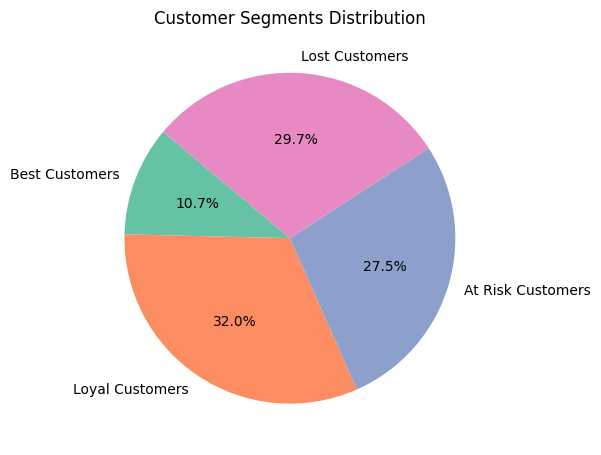

In [ ]:

# Convert 'Order_Date' to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Step 1: Define snapshot date (day after last order)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Step 2: Calculate RFM metrics per customer

# Recency: days since last order
recency = df.groupby('Customer_ID')['Order_Date'].apply(lambda x: (snapshot_date - x.max()).days)

# Frequency: count of orders
frequency = df.groupby('Customer_ID')['Order_Date'].count()

# Monetary: total revenue
monetary = df.groupby('Customer_ID')['Revenue_USD'].sum()

# Combine into one RFM dataframe
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# Filter out customers with zero or negative revenue if any
rfm = rfm[rfm['Monetary'] > 0]

# Step 3: Scale RFM values for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Step 4: Apply KMeans clustering into 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

# Step 5: Assign descriptive category names based on cluster Recency mean
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Recency')

category_map = {}
for i, cluster in enumerate(cluster_summary.index):
    if i == 0:
        category_map[cluster] = 'Best Customers'
    elif i == 1:
        category_map[cluster] = 'Loyal Customers'
    elif i == 2:
        category_map[cluster] = 'At Risk Customers'
    else:
        category_map[cluster] = 'Lost Customers'

rfm['Category'] = rfm['Cluster'].map(category_map)

# Step 6: Plot counts of each category (bar plot)
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Category', order=['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers'], palette='Set2')
plt.title('Customer Segments Count')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Step 7: Plot pie chart for category distribution
plt.figure(figsize=(6,6))
rfm['Category'].value_counts().loc[['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers']].plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=140)
plt.ylabel('')
plt.title('Customer Segments Distribution')
plt.tight_layout()
plt.show()


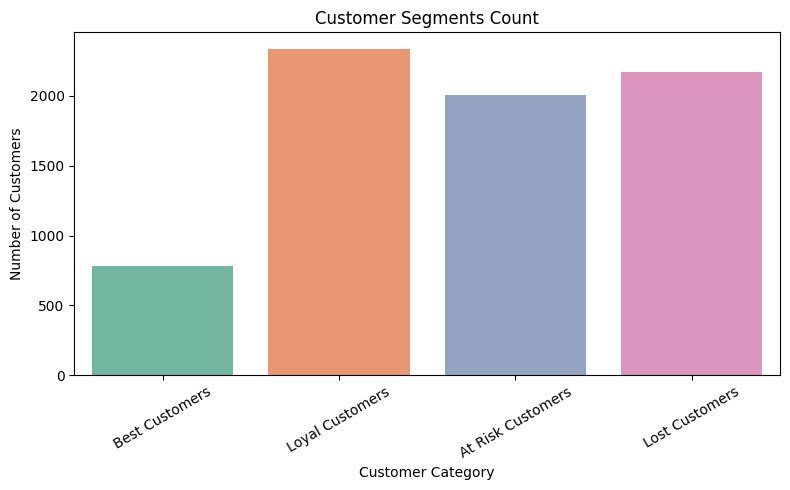

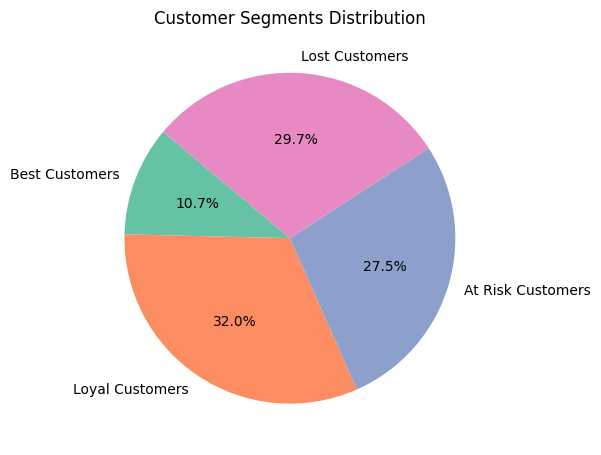

In [ ]:

# Convert 'Order_Date' to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Step 1: Define snapshot date (day after last order)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Step 2: Calculate RFM metrics per customer

# Recency: days since last order
recency = df.groupby('Customer_ID')['Order_Date'].apply(lambda x: (snapshot_date - x.max()).days)

# Frequency: count of orders
frequency = df.groupby('Customer_ID')['Order_Date'].count()

# Monetary: total revenue
monetary = df.groupby('Customer_ID')['Revenue_USD'].sum()

# Combine into one RFM dataframe
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# Filter out customers with zero or negative revenue if any
rfm = rfm[rfm['Monetary'] > 0]

# Step 3: Scale RFM values for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Step 4: Apply KMeans clustering into 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

# Step 5: Assign descriptive category names based on cluster Recency mean
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values(by='Recency')

category_map = {}
for i, cluster in enumerate(cluster_summary.index):
    if i == 0:
        category_map[cluster] = 'Best Customers'
    elif i == 1:
        category_map[cluster] = 'Loyal Customers'
    elif i == 2:
        category_map[cluster] = 'At Risk Customers'
    else:
        category_map[cluster] = 'Lost Customers'

rfm['Category'] = rfm['Cluster'].map(category_map)

# Step 6: Plot counts of each category (bar plot)
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Category', order=['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers'], palette='Set2')
plt.title('Customer Segments Count')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Step 7: Plot pie chart for category distribution
plt.figure(figsize=(6,6))
rfm['Category'].value_counts().loc[['Best Customers', 'Loyal Customers', 'At Risk Customers', 'Lost Customers']].plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=140)
plt.ylabel('')
plt.title('Customer Segments Distribution')
plt.tight_layout()
plt.show()
